In [76]:
from pathlib import Path

IMAGES_PATH = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")

def index_labeled_images(images_path=IMAGES_PATH, max_per_class=3000):
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        count = 0
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            if count >= max_per_class:
                break
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }
            count += 1

    return labeled_images

In [77]:
labeled_images = index_labeled_images()

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm.auto import tqdm

def extract_labels(labeled_images):
    labels = []
    paths = []
    for (i, image_name) in enumerate(labeled_images):
        path = labeled_images[image_name]['path']
        paths.append(path)
        label = labeled_images[image_name]['label']
        labels.append(label)

    return paths, np.array(labels)

In [79]:
paths, labels = extract_labels(labeled_images)

In [80]:
print(labels)

['Ac' 'Ac' 'Ac' ... 'St' 'St' 'St']


In [81]:
print(paths)

['../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061746_GE_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061746_GN_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061746_GS_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061746_GU_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061746_GW_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061813_GE_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061813_GN_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061813_GS_Ac.jpg', '../resources/cloud-images/NASA_GLOBE_CD/downloaded_images/Ac/101-125549-20826653-201909061813_GU_Ac.jpg', '../resources/cloud-images/NASA_GLOB

In [82]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [83]:
# augmentation

import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

def color_jitter_if_rgb(x):
    return T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02)(x) if x.ndim == 3 and x.shape[0] == 3 else x

IMG_SIZE = (384, 384)  # required by ViT_B_16 SWAG weights
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [84]:
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
from functools import partial

In [85]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [86]:
list(torchvision.models.get_model_weights("vit_b_16"))

[ViT_B_16_Weights.IMAGENET1K_V1,
 ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1,
 ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1]

In [87]:
weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
model = torchvision.models.vit_b_16(weights=weights).to(device)

In [88]:
import torchvision.transforms.v2 as T

transforms = weights.transforms()
# transforms = T.Compose([
#     T.RandomHorizontalFlip(p=0.5),
#     T.RandomRotation(degrees=30),
#     T.RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0)),
#     T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     T.ToImage(),
#     T.ToDtype(torch.float32, scale=True),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])

In [89]:
print(transforms)

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [90]:
from sklearn.preprocessing import LabelEncoder

def encode_labels(labels):
    ordinal_encoder = LabelEncoder()
    encoded_labels = ordinal_encoder.fit_transform(labels)
    class_names = ordinal_encoder.classes_
    return encoded_labels, class_names


In [91]:
encoded_labels, class_names = encode_labels(labels)

In [92]:
print(class_names)

['Ac' 'As' 'Cb' 'Cc' 'Ci' 'ClSk' 'Cs' 'Ct' 'Cu' 'Ns' 'Sc' 'St']


In [93]:
print(encoded_labels)

[ 0  0  0 ... 11 11 11]


In [94]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
import numpy as np

class MyImages(Dataset):
    def __init__(self, paths, encoded_labels, split="train", test_size=0.2, val_size=0.1, random_state=42, transform=None,
                 split_indices=None):

        if split not in {None, "train", "val", "test"}:
            raise ValueError(f"split must be one of {{'None','train','val','test'}}, got {split!r}")

        self.transform = transform

        paths = np.array(list(paths))
        encoded_labels = np.array(list(encoded_labels))

        n = len(paths)
        if n != len(encoded_labels):
            raise ValueError(f"paths and encoded_labels must have same length, got {n} and {len(labels)}")

        if split_indices is None:
            sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
            trainval_idx, test_idx = next(sss1.split(paths, encoded_labels))

            trainval_fraction = 1.0 - test_size
            val_within_trainval = val_size / trainval_fraction

            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_within_trainval, random_state=random_state)

            trainval_paths = paths[trainval_idx]
            trainval_labels = encoded_labels[trainval_idx]

            train_rel_idx, val_rel_idx = next(sss2.split(trainval_paths, trainval_labels))
            train_idx = trainval_idx[train_rel_idx]
            val_idx = trainval_idx[val_rel_idx]

            split_indices = {"train": train_idx, "val": val_idx, "test": test_idx}

        idx = split_indices[split]

        self.paths = paths[idx].tolist()
        self.encoded_labels = encoded_labels[idx].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


In [95]:
from functools import partial

DefaultCloudImages = partial(
    MyImages,
    paths=paths,
    encoded_labels=encoded_labels,
    transform=transforms,
    test_size=0.2,
    val_size=0.1,
    random_state=42
)

In [96]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

paths_arr = np.array(list(paths))
labels_arr = np.array(list(encoded_labels))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(sss1.split(paths_arr, labels_arr))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.8, random_state=42)
train_rel_idx, val_rel_idx = next(sss2.split(paths_arr[trainval_idx], labels_arr[trainval_idx]))

split_indices = {
    "train": trainval_idx[train_rel_idx],
    "val":   trainval_idx[val_rel_idx],
    "test":  test_idx,
}

train_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="train", transform=train_transforms,
                     split_indices=split_indices)

valid_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="val", transform=eval_transforms,
                     split_indices=split_indices)

test_set  = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="test", transform=eval_transforms,
                     split_indices=split_indices)

In [97]:
train_set[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [98]:
len(train_set)
len(valid_set)
len(test_set)

6110

In [99]:
display_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])

# create a dataset instance for the train split (use MyImages to request a split)
clouds_to_display = DefaultCloudImages(split="train", transform=display_transform)


In [100]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

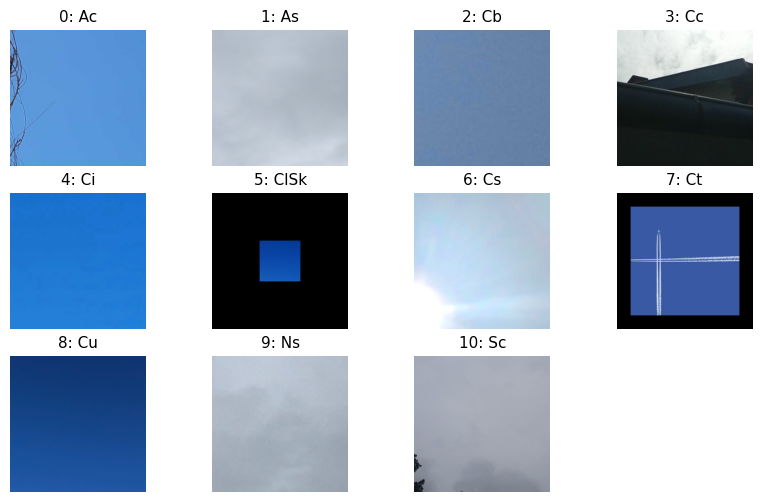

In [101]:
sample_clouds = {}
for img, y in clouds_to_display:
    if y not in sample_clouds:
        sample_clouds[y] = img
    if len(sample_clouds) == len(class_names):
        break

sample_clouds = sorted(sample_clouds.items())[:11]

plt.figure(figsize=(10, 6))
for class_id, image in sample_clouds:
    if class_id == 11: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [102]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

train_labels_list = [train_set.encoded_labels[i] for i in range(len(train_set))]
class_counts = np.bincount(train_labels_list)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[l] for l in train_labels_list], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_set, batch_size=32, sampler=sampler, num_workers=4, pin_memory=False)  # no shuffle=True
valid_loader = DataLoader(valid_set, batch_size=32, num_workers=4, pin_memory=False)
test_loader  = DataLoader(test_set,  batch_size=32, num_workers=4, pin_memory=False)

In [103]:
[name for name, child in model.named_children()]

['conv_proj', 'encoder', 'heads']

In [104]:
model.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [105]:
model.encoder

Encoder(
  (dropout): Dropout(p=0.0, inplace=False)
  (layers): Sequential(
    (encoder_layer_0): EncoderBlock(
      (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLPBlock(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=3072, out_features=768, bias=True)
        (4): Dropout(p=0.0, inplace=False)
      )
    )
    (encoder_layer_1): EncoderBlock(
      (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
    

In [106]:
model.conv_proj

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

In [107]:
n_classes = 11
model.heads = nn.Sequential(nn.Dropout(p=0.1), nn.Linear(768, n_classes)).to(device)

In [108]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

In [109]:
import os
from tqdm.auto import tqdm

FEATURES_PATH = "cached_features"
os.makedirs(FEATURES_PATH, exist_ok=True)

def extract_features(model, loader, device):
    model.eval()
    all_features, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(device)
            x = model._process_input(imgs)
            n = x.shape[0]
            batch_class_token = model.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)
            x = model.encoder(x)
            x = x[:, 0]  # 768-dim class token output
            all_features.append(x.cpu())
            all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

if not os.path.exists(f"{FEATURES_PATH}/train.pt"):
    extract_train_loader = DataLoader(train_set, batch_size=32, num_workers=0)
    extract_valid_loader = DataLoader(valid_set, batch_size=32, num_workers=0)
    extract_test_loader  = DataLoader(test_set,  batch_size=32, num_workers=0)

    print("Extracting train features...")
    train_feats, train_feat_labels = extract_features(model, extract_train_loader, device)
    torch.save({"features": train_feats, "labels": train_feat_labels}, f"{FEATURES_PATH}/train.pt")

    print("Extracting val features...")
    val_feats, val_feat_labels = extract_features(model, extract_valid_loader, device)
    torch.save({"features": val_feats, "labels": val_feat_labels}, f"{FEATURES_PATH}/val.pt")

    print("Extracting test features...")
    test_feats, test_feat_labels = extract_features(model, extract_test_loader, device)
    torch.save({"features": test_feats, "labels": test_feat_labels}, f"{FEATURES_PATH}/test.pt")

    print(f"Done. Train: {train_feats.shape}, Val: {val_feats.shape}, Test: {test_feats.shape}")
else:
    print("Cached features found on disk, skipping extraction.")

Extracting train features...


100%|██████████| 669/669 [16:24<00:00,  1.47s/it]


Extracting val features...


100%|██████████| 96/96 [02:09<00:00,  1.35s/it]


Extracting test features...


100%|██████████| 191/191 [04:20<00:00,  1.36s/it]

Done. Train: torch.Size([21384, 768]), Val: torch.Size([3055, 768]), Test: torch.Size([6110, 768])


In [110]:
from torch.utils.data import TensorDataset

train_data = torch.load(f"{FEATURES_PATH}/train.pt", weights_only=True)
val_data   = torch.load(f"{FEATURES_PATH}/val.pt",   weights_only=True)
test_data  = torch.load(f"{FEATURES_PATH}/test.pt",  weights_only=True)

feat_train_set = TensorDataset(train_data["features"], train_data["labels"])
feat_val_set   = TensorDataset(val_data["features"],   val_data["labels"])
feat_test_set  = TensorDataset(test_data["features"],  test_data["labels"])

feat_class_counts  = np.bincount(train_data["labels"].numpy())
feat_class_weights = 1.0 / feat_class_counts
feat_sample_weights = torch.tensor(
    [feat_class_weights[l] for l in train_data["labels"].numpy()], dtype=torch.float
)
feat_sampler = WeightedRandomSampler(feat_sample_weights, len(feat_sample_weights), replacement=True)

feat_train_loader = DataLoader(feat_train_set, batch_size=256, sampler=feat_sampler)
feat_valid_loader = DataLoader(feat_val_set,   batch_size=256)
feat_test_loader  = DataLoader(feat_test_set,  batch_size=256)

In [111]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=20, checkpoint_path="best_model.pt"):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    best_val = 0.0
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        history["train_losses"].append(train_loss)
        history["train_metrics"].append(train_acc)
        history["valid_metrics"].append(val_acc)

        print(f"Epoch {epoch + 1}/{n_epochs} | "
              f"loss: {train_loss:.4f} | "
              f"train: {train_acc:.4f} | "
              f"val: {val_acc:.4f}"
              + (" *" if val_acc > best_val else ""))

        if val_acc > best_val:
            best_val = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch + 1} (best val: {best_val:.4f})")
                break

    model.load_state_dict(torch.load(checkpoint_path))
    return history

In [113]:
n_epochs = 300
optimizer = torch.optim.AdamW(model.heads.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=11).to(device)

history = train(model.heads, optimizer, xentropy, accuracy,
                feat_train_loader, feat_valid_loader, n_epochs,
                patience=100, checkpoint_path="best_model.pt")

print(f"Test accuracy: {evaluate_tm(model.heads, feat_test_loader, accuracy):.4f}")

Epoch 1/300 | loss: 0.9976 | train: 0.5589 | val: 0.4622 *
Epoch 2/300 | loss: 1.0000 | train: 0.5590 | val: 0.4642 *
Epoch 3/300 | loss: 1.0124 | train: 0.5547 | val: 0.4619
Epoch 4/300 | loss: 0.9935 | train: 0.5592 | val: 0.4498
Epoch 5/300 | loss: 1.0073 | train: 0.5596 | val: 0.4619
Epoch 6/300 | loss: 0.9890 | train: 0.5579 | val: 0.4619
Epoch 7/300 | loss: 0.9928 | train: 0.5588 | val: 0.4710 *
Epoch 8/300 | loss: 1.0028 | train: 0.5534 | val: 0.4632
Epoch 9/300 | loss: 0.9889 | train: 0.5626 | val: 0.4678
Epoch 10/300 | loss: 0.9790 | train: 0.5642 | val: 0.4684
Epoch 11/300 | loss: 0.9908 | train: 0.5614 | val: 0.4615
Epoch 12/300 | loss: 0.9814 | train: 0.5669 | val: 0.4586
Epoch 13/300 | loss: 0.9767 | train: 0.5642 | val: 0.4691
Epoch 14/300 | loss: 0.9963 | train: 0.5596 | val: 0.4622
Epoch 15/300 | loss: 0.9959 | train: 0.5592 | val: 0.4504
Epoch 16/300 | loss: 0.9862 | train: 0.5614 | val: 0.4592
Epoch 17/300 | loss: 0.9923 | train: 0.5604 | val: 0.4625
Epoch 18/300 | lo